<a href="https://colab.research.google.com/github/seik345/EstadisticaVerano2026/blob/main/ProblemarioU4/Problemario_U4_said.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Analiza los siguientes diseños experimentales, e intenta sacar el máximo valor a la información. Verifica los supuestos (linealidad, homscedasticidad e independencia), puedes apoyarte en [la guía de la unidad 4](https://github.com/DrFaus/Estadistica2026B/blob/main/DiseniosExperimentalesUnFactor.ipynb). Aplica una prueba post-hoc en caso que sea necesario. Redacta una conclusión y una recomendación para las personas que recolectaron los datos.

1. **Comparación de cuatro métodos de ensamble:** Un equipo de mejora investiga el efecto de cuatro métodos de ensamble A, B, C y D, sobre el tiempo de ensamble en minutos. En primera instancia, la estrategia experimental es aplicar cuatro veces los cuatro métodos de ensamble en orden completamente aleatorio (las 16 pruebas en orden aleatorio). Los tiempos de ensamble obtenidos se muestran en la tabla 3.1. Si se usa el diseño completamente al azar (DCA), se supone que, además del método de ensamble, no existe ningún otro factor que influya de manera significativa sobre la variable de respuesta (tiempo de ensamble).

| Método de ensamble | A  | B  | C  | D  |
|--------------------|----|----|----|----|
|                    | 6  | 7  | 11 | 10 |
|                    | 8  | 9  | 16 | 12 |
|                    | 7  | 10 | 11 | 11 |
|                    | 8  | 8  | 13 | 9  |


In [ ]:
# Oscar Said Valenciano Gallegos
import pandas as pd
from io import StringIO

datos='''
metodo,minutos
A,6
B,7
C,11
D,10
A,8
B,9
C,16
D,12
A,7
B,10
C,11
D,11
A,8
B,8
C,13
D,9
'''

df=pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)
df

,metodo,minutos
0,A,6
1,B,7
2,C,11
3,D,10
4,A,8
5,B,9
6,C,16
7,D,12
8,A,7
9,B,10


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Hipotesis
#H0: mu_1 = mu_2 = mu_3
#H1: al menos una media es diferente

modelo = ols('minutos ~ C(metodo)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) #round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(metodo),69.5,3.0,9.4237,0.0018
Residual,29.5,12.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.2808008139238355


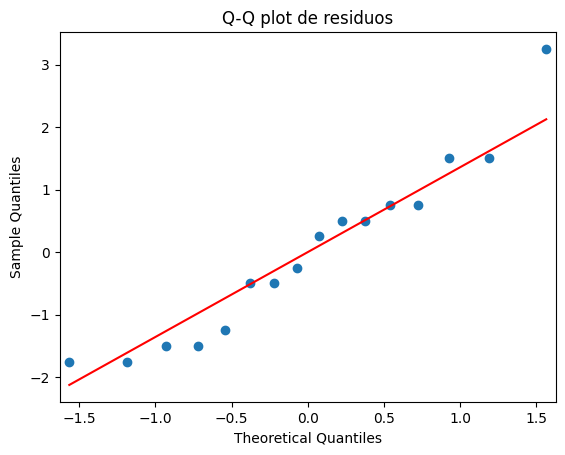

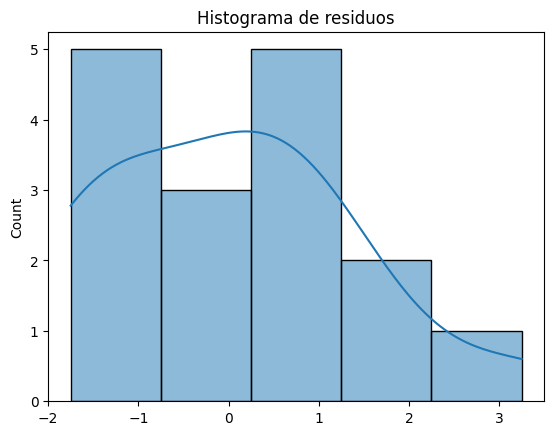

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals from the fitted model
residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['metodo'] == 'A']['minutos']
grupo_B = df[df['metodo'] == 'B']['minutos']
grupo_C = df[df['metodo'] == 'C']['minutos']
grupo_D = df[df['metodo'] == 'D']['minutos']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.9474
p-valor: 0.4485


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B     1.25 0.6805 -2.0416 4.5416  False
     A      C      5.5 0.0016  2.2084 8.7916   True
     A      D     3.25 0.0533 -0.0416 6.5416  False
     B      C     4.25  0.011  0.9584 7.5416   True
     B      D      2.0 0.3181 -1.2916 5.2916  False
     C      D    -2.25 0.2309 -5.5416 1.0416  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

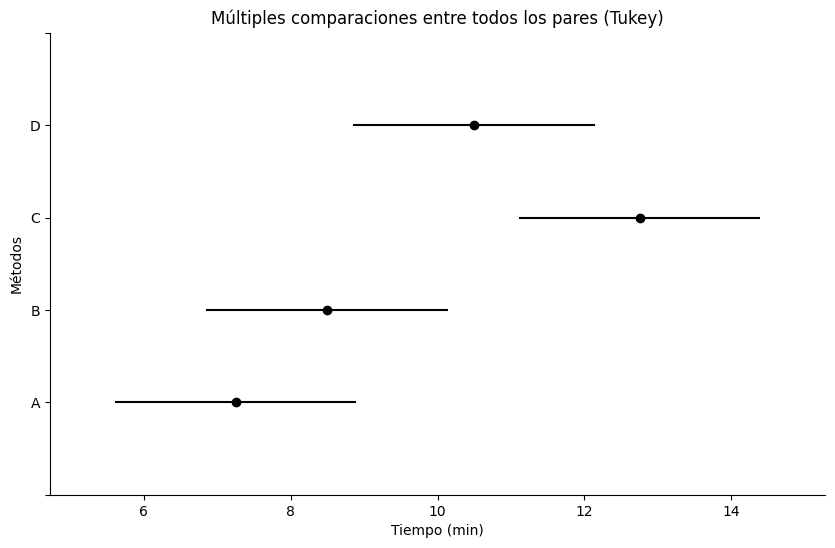

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['minutos'], # Variable de respuesta
    groups=df['metodo'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Métodos", xlabel="Tiempo (min)")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método

df.groupby(["metodo"]).mean()["minutos"]

,minutos
metodo,
A,7.25
B,8.50
C,12.75
D,10.50


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from math import sqrt

# Re-calculate tabla_anova as it seems not to be defined in the current scope.
# This assumes 'df' is the dataframe for the current problem context.

modelo = ols('minutos ~ C(metodo)', data=df).fit()
tabla_anova = sm.stats.anova_lm(modelo, typ=2)

eta_squared = tabla_anova['sum_sq']['C(metodo)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.702


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["metodo"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.7020
f de Cohen = 1.5349
Potencia de la prueba = 0.9956


**CONCLUSION**

El diseño experimental en un DCA con los supuestos de normalidad y homocedasticidad. Segun el test de de ANOVA hay diferencia significativa en almenos un metodo C es el unico que muestra una diferencia significativa respecto a los demas. Sin embargo el metodo C aumenta el tiempo estimado de ensamble, por los que recomendamos evitarlo y usar en cambio el metodo A, B o D. Aunque el metodo A mostro mejores resultados en este experimento, no se encontro una diferencia significativa con el metodo B o D

El tamaño del efecto es de 0.702, lo que indica que el cambio en los metodos de ensamble justifica en un 70.2% los cambios observados en los tiempos de ensamble. La potencia de la prueba de 0.9956 indica que tenemos un 99.56% de probabilidad de rechazar la hipotesis nula dado que es falsa. Esto le da mucho sustento a los resultados observados.

Si queisieramos trabajar con una potencia de la prueba del 80% solo hacia faltan 3 observaciones por grupo. Al tener 4, reforzamos las conclusiones del estudio

2. **Comparación de cuatro tipos de cuero:** Un fabricante de calzado desea mejorar la calidad de las suelas, las cuales se pueden hacer con uno de los cuatro tipos de cuero A, B, C y D disponibles en el mercado. Para ello, prueba los cueros con una máquina que hace pasar los zapatos por una superficie abrasiva; la suela de éstos se desgasta al pasarla por dicha superficie. Como criterio de desgaste se usa la pérdida de peso después de un número fijo de ciclos. Se prueban en orden aleatorio 24 zapatos, seis de cada tipo de cuero. Al hacer las pruebas en orden completamente al azar se evitan sesgos y las mediciones en un tipo de cuero resultan independientes de las demás. Los datos (en miligramos) sobre el desgaste de cada tipo de cuero se muestran en la tabla.

| Tipo de cuero | Observaciones                  | Promedio |
|---------------|--------------------------------|----------|
| A             | 264, 260, 258, 241, 262, 255 | 256.7    |
| B             | 208, 220, 216, 200, 213, 206 | 209.8    |
| C             | 220, 263, 219, 225, 230, 228 | 230.8    |
| D             | 217, 226, 215, 227, 220, 222 | 220.7    |


In [ ]:
# Oscar Said Valenciano Gallegos
import pandas as pd
from io import StringIO

datos='''
cuero,observaciones
A,264
B,208
C,220
D,217
A,260
B,220
C,263
D,226
A,258
B,216
C,219
D,215
A,241
B,200
C,225
D,227
A,262
B,213
C,230
D,220
A,255
B,206
C,228
D,222
'''

df=pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)
df

,cuero,observaciones
0,A,264
1,B,208
2,C,220
3,D,217
4,A,260
5,B,220
6,C,263
7,D,226
8,A,258
9,B,216


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Hipotesis
#H0: mu_1 = mu_2 = mu_3
#H1: al menos una media es diferente

modelo = ols('observaciones ~ C(cuero)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) #round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(cuero),7019.4583,3.0,22.7554,0.0
Residual,2056.5000,20.0,NaN,NaN


Aqui tuvimos que usar el codigo de anova para comparar las medias, de parte de la variabilidad explicada por el tipo de cuero nos dio 7019.4583

In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.009670145138301391


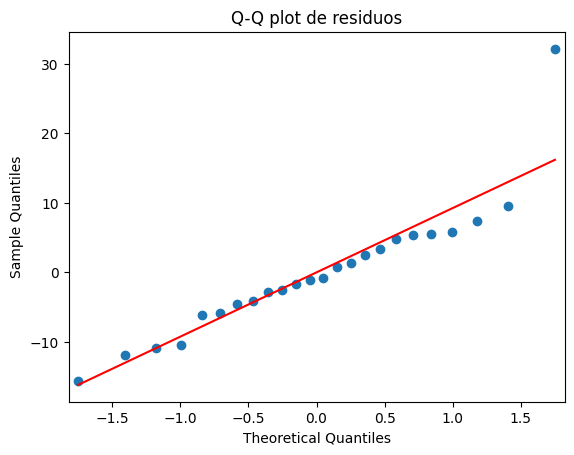

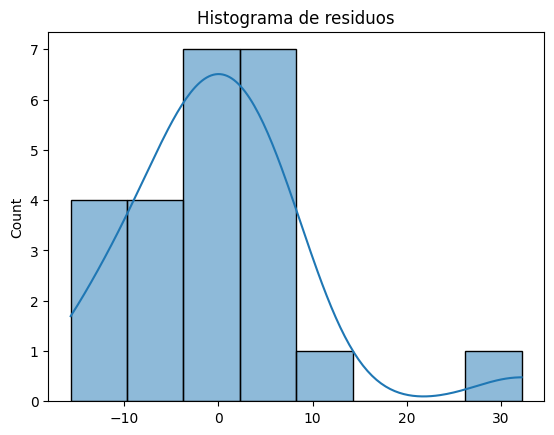

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals from the fitted model
residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

De parte del test de shapiro nos dio un resultado de $.009$ lo que significa que no hay normalidad

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['cuero'] == 'A']['observaciones']
grupo_B = df[df['cuero'] == 'B']['observaciones']
grupo_C = df[df['cuero'] == 'C']['observaciones']
grupo_D = df[df['cuero'] == 'D']['observaciones']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.5797
p-valor: 0.6351


De parte del test de levene, vemos que nos dio .6351 lo que significa que si hay homocedasticidad

Como vemos que de un metodo no cumple, entonces tenemos que usar el metodo de boxcox

Lambda óptimo: -3.707788382033557


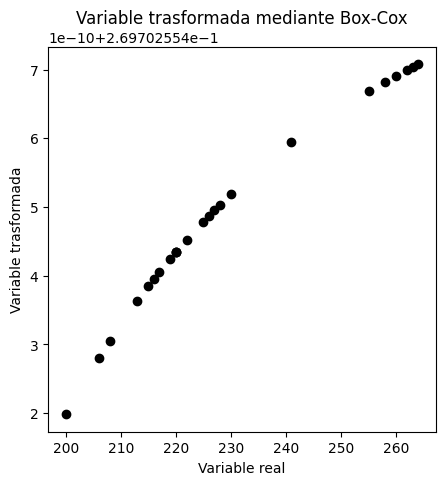

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["observaciones_boxcox"], lambda_opt = boxcox(df["observaciones"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["observaciones"], df["observaciones_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('observaciones_boxcox ~ C(cuero)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(cuero),0.0,3.0,23.3682,0.0
Residual,0.0,20.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.4576969192784245


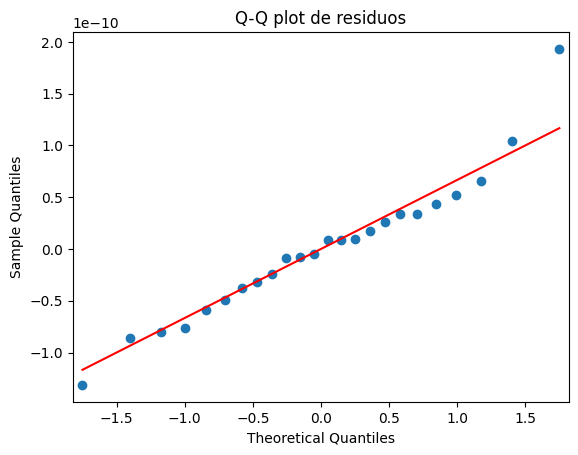

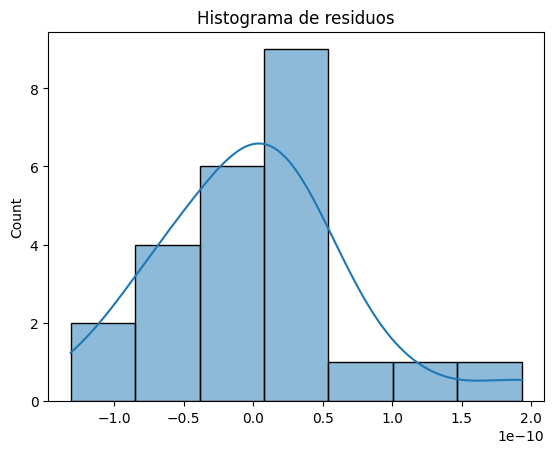

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Una vez hecho el metodo de boxcox tenemos un resultado de .4576 lo que significa que si hay normalidad

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['cuero'] == 'A']['observaciones_boxcox']
grupo_B = df[df['cuero'] == 'B']['observaciones_boxcox']
grupo_C = df[df['cuero'] == 'C']['observaciones_boxcox']
grupo_D = df[df['cuero'] == 'D']['observaciones_boxcox']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 1.1788
p-valor: 0.3428


De parte del test de levene, despues del metodo de boxcox nos dio un resultado de .3428 lo que significa que hay homocedasticidad

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower upper reject
------------------------------------------------
     A      B     -0.0    0.0  -0.0  -0.0   True
     A      C     -0.0 0.0048  -0.0  -0.0   True
     A      D     -0.0 0.0001  -0.0  -0.0   True
     B      C      0.0 0.0018   0.0   0.0   True
     B      D      0.0 0.0613  -0.0   0.0  False
     C      D     -0.0  0.401  -0.0   0.0  False
------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

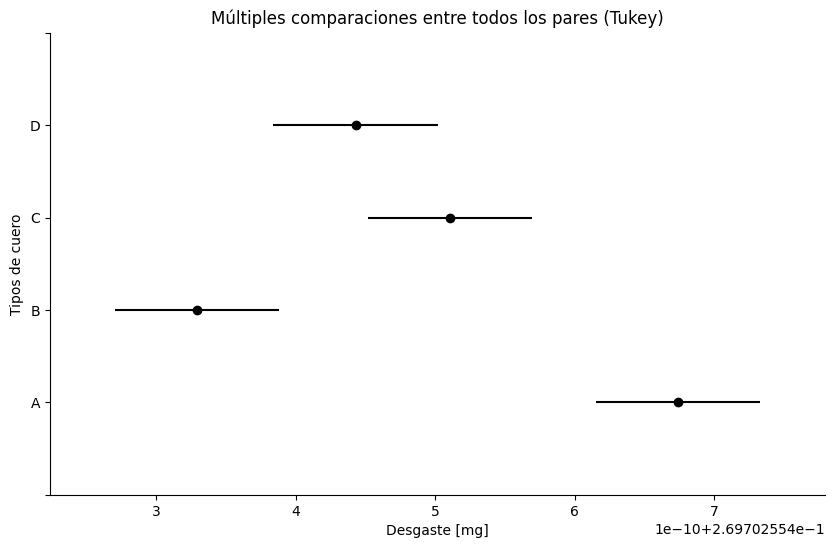

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['observaciones_boxcox'], # Variable de respuesta
    groups=df['cuero'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tipos de cuero", xlabel="Desgaste [mg]")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["cuero"]).mean()["observaciones"]

,observaciones
cuero,
A,256.666667
B,210.500000
C,230.833333
D,221.166667


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(cuero)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.778


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["cuero"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.7780
f de Cohen = 1.8722
Potencia de la prueba = 1.0000


**CONCLUSION**

Hemos hecho un análisis y seguido un procedimiento que les mostraremos a continuación, de parte del test de anova nos dio una variabilidad de $7019.4583$ que nos dio por el tipo de cuero, de parte de shapiro wilk nos dio $.009$, lo que significa que no sigue normalidad, en cambio de parte del test de levene nos dio $.6351$ lo que significa que si hay homocedasticidad. Sin embargo, de parte del test de shapiro no cumple, entonces tenemos que usar el método de boxcox.

Una vez hecho el método de boxcox vemos que ya cumplen los dos test, de parte de shapiro nos dio $.457$ lo que significa que si hay normalidad y de parte de levene nos dio $.3428$ lo que significa que si hay homocedasticidad.

 Para poder tener el conocimiento que los tipos de cuero que dan menor desgaste son el cuero **B y D**. y como recomendación el que da mas desgate es el cuero A y les sugerimos que **no lo utilizen**

3. En un centro de investigación se realiza un estudio para comparar varios tratamientos que, al aplicarse previamente a los frijoles crudos, reducen su tiempo de cocción. Estos tratamientos son a base de bicarbonato de sodio y cloruro de sodio o sal común. El primer tratamiento ($T_1$) es el de control, que consiste en no aplicar ningún tratamiento. El tratamiento $T_2$ es el remojo en agua con bicarbonato de sodio, el $T_3$ es remojar en agua con sal común y el $T_4$ es remojar en agua con una combinación de ambos ingredientes en proporciones iguales. La variable de respuesta es el tiempo de cocción en minutos. Los datos se muestran en la siguiente tabla:

| $T_1$ | $T_2$  | $T_3$  | $T_4$  |
|---------|-----|-----|-----|
| 213     | 76  | 57  | 84  |
| 214     | 85  | 67  | 82  |
| 204     | 74  | 55  | 85  |
| 208     | 78  | 64  | 92  |
| 212     | 82  | 61  | 87  |
| 200     | 75  | 63  | 79  |
| 207     | 82  | 63  | 90  |



In [ ]:
# Oscar Said Valenciano Gallegos
import pandas as pd
from io import StringIO

datos='''
tratamientos,coccion
T1,213
T2,76
T3,57
T4,84
T1,214
T2,85
T3,67
T4,82
T1,204
T2,74
T3,55
T4,85
T1,208
T2,78
T3,64
T4,92
T1,212
T2,82
T3,61
T4,87
T1,200
T2,75
T3,63
T4,79
T1,207
T2,82
T3,63
T4,90
'''

df=pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)
df

,tratamientos,coccion
0,T1,213
1,T2,76
2,T3,57
3,T4,84
4,T1,214
5,T2,85
6,T3,67
7,T4,82
8,T1,204
9,T2,74


In [ ]:
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_T1 = mu_T2 = mu_T3 = mu_T4
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('coccion ~ C(tratamientos)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tratamientos),95041.2500,3.0,1558.966,0.0
Residual,487.7143,24.0,NaN,NaN


Aqui tuvimos que usar el codigo de anova para comparar las medias, de parte de la variabilidad explicada por el tipo de cuero nos dio 95041.2500

In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.34689165649615683


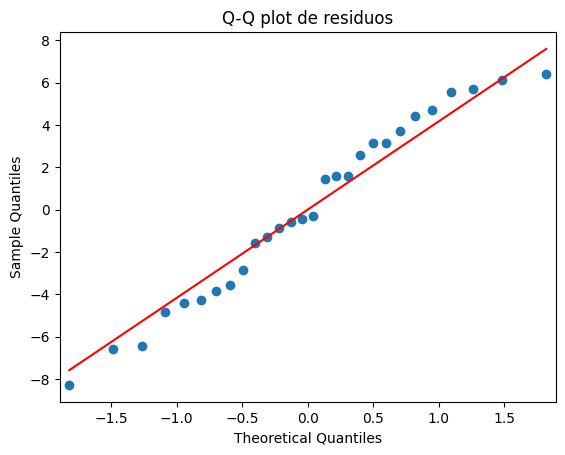

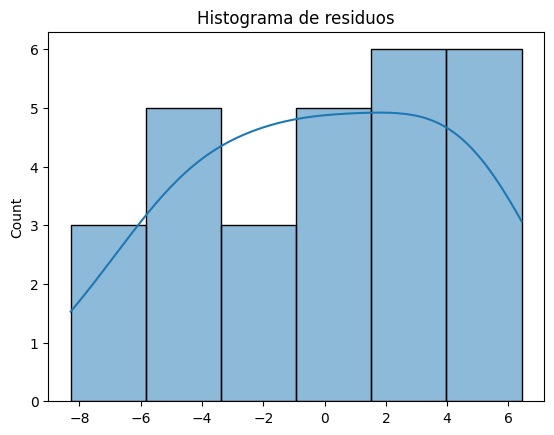

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Haciendo el test de de shapiro wilk, lo que nos dio un resultado de $.3468$, lo que nos indica que **hay normalidad**

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['tratamientos'] == 'T1']['coccion']
grupo_B = df[df['tratamientos'] == 'T2']['coccion']
grupo_C = df[df['tratamientos'] == 'T3']['coccion']
grupo_D = df[df['tratamientos'] == 'T4']['coccion']

stat, p = levene(grupo_A, grupo_B, grupo_C, grupo_D)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.1631
p-valor: 0.9201


De parte del test de levene, nos dio un resultado de $.9201$ lo que signifa que es muy fuerte y significa que **hay homocedasticidad**

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower     upper   reject
---------------------------------------------------------
    T1     T2 -129.4286    0.0 -136.0757 -122.7815   True
    T1     T3 -146.8571    0.0 -153.5043   -140.21   True
    T1     T4 -122.7143    0.0 -129.3614 -116.0672   True
    T2     T3  -17.4286    0.0  -24.0757  -10.7815   True
    T2     T4    6.7143 0.0471    0.0672   13.3614   True
    T3     T4   24.1429    0.0   17.4957     30.79   True
---------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

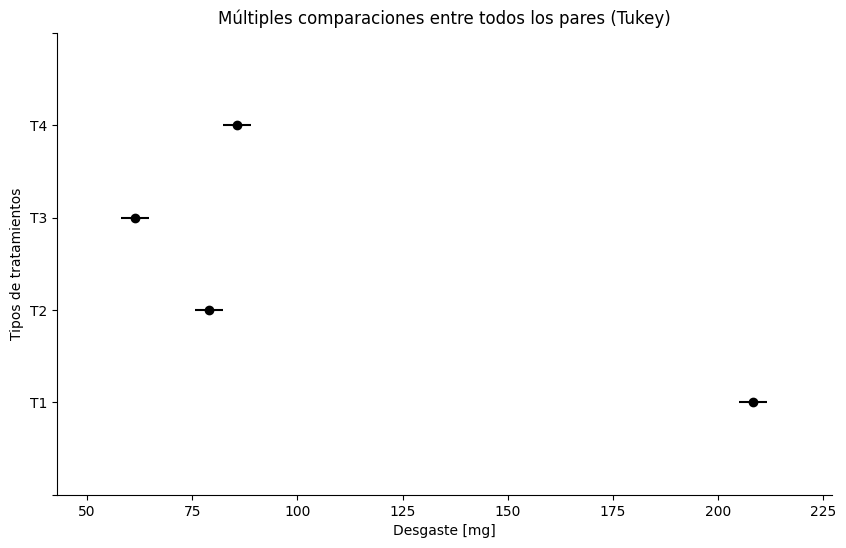

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['coccion'], # Variable de respuesta
    groups=df['tratamientos'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tipos de tratamientos", xlabel="Desgaste [mg]")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["tratamientos"]).mean()["coccion"]

,coccion
tratamientos,
T1,208.285714
T2,78.857143
T3,61.428571
T4,85.571429


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(tratamientos)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.995


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["tratamientos"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9949
f de Cohen = 13.9596
Potencia de la prueba = 1.0000


**CONCLUSION**

Analizando la base de datos del centro de investigación para comparar los tipo de tratamientos y que se puedan aplicar a los frijoles crudos y que se reduzca el tiempo de cocción.

 Cada tratamiento tiene un nombre en específico, el primero tiene el deber del control, remojo de agua con bicarbonato, remojar con agua y sal y el cuarto es aplicar el tratamiento 2 y 3.

 Para saber cuál método es el mejor, tenemos que usar el teste de anova, el test de shapiro el cual nos dio un resultado de $0.3468$, lo que significa que hay normalidad, el siguiente es el test de levene el cual nos dio un resultado de $0.9201$ lo cual significa que hay homocedasticidad.

  Una vez que los dos test nos den los resultados esperados hacemos el test de tukey y vemos que los tratamientos que son mejor opción aplicarlos los cuales son el T3 como primea opción, el T2 como tercera opción pero como recomendación seria que no utilizaran el tratamiento 1

4. Para estudiar la confiabilidad de ciertos tableros electrónicos para carros, se someten a un envejecimiento acelerado durante 100 horas a determinada temperatura, y como variable de interés se mide la intensidad de corriente que circula entre dos puntos, cuyos valores aumentan con el deterioro. Se probaron 20 módulos repartidos de manera equitativa en cinco temperaturas y los resultados obtenidos fueron los siguientes:

| 20°C | 40°C | 60°C | 80°C | 100°C |
|------|------|------|------|-------|
| 15   | 17   | 23   | 28   | 45    |
| 18   | 21   | 19   | 32   | 51    |
| 13   | 11   | 25   | 34   | 57    |
| 12   | 16   | 22   | 31   | 48    |


In [ ]:
# Oscar Said Valenciano Gallegos
import pandas as pd
from io import StringIO

datos='''
tableros,temperatura
20'C,15
40'C,17
60'C,23
80'C,28
100'C,45
20'C,18
40'C,21
60'C,19
80'C,32
100'C,51
20'C,13
40'C,11
60'C,25
80'C,34
100'C,57
20'C,12
40'C,16
60'C,22
80'C,31
100'C,48
'''

df=pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)
df

,tableros,temperatura
0,20'C,15
1,40'C,17
2,60'C,23
3,80'C,28
4,100'C,45
5,20'C,18
6,40'C,21
7,60'C,19
8,80'C,32
9,100'C,51


In [ ]:
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_T1 = mu_T2 = mu_T3 = mu_T4
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('temperatura ~ C(tableros)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tableros),3411.8,4.0,68.0545,0.0
Residual,188.0,15.0,NaN,NaN


Aqui tuvimos que usar el codigo de anova para comparar las medias, de parte de la variabilidad explicada por el tipo de cuero nos dio 3411.8

In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.7785351257478303


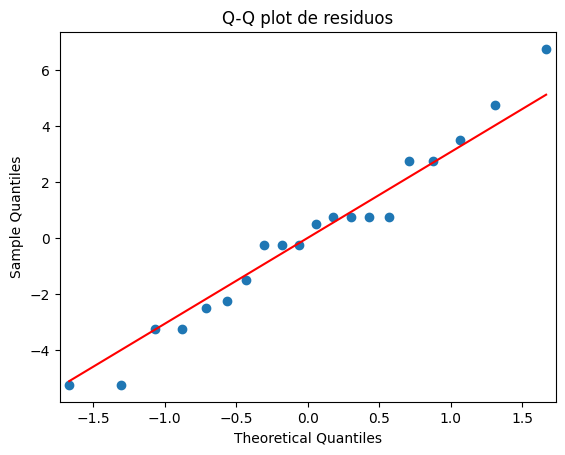

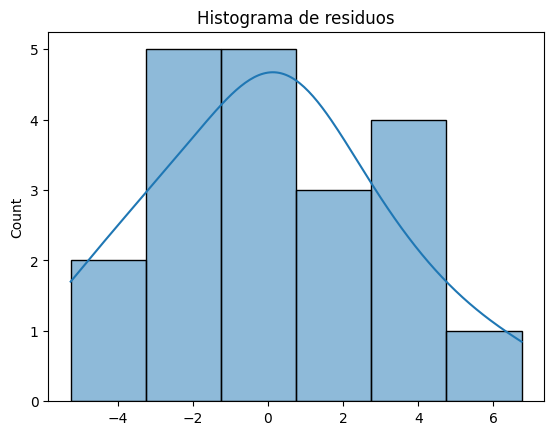

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Haciendo el test de de shapiro wilk, lo que nos dio un resultado de $.7785$, lo que nos indica que **hay normalidad**

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_20 = df[df['tableros'] == "20'C"]['temperatura']
grupo_40 = df[df['tableros'] == "40'C"]['temperatura']
grupo_60 = df[df['tableros'] == "60'C"]['temperatura']
grupo_80 = df[df['tableros'] == "80'C"]['temperatura']
grupo_100 = df[df['tableros'] == "100'C"]['temperatura']

stat, p = levene(grupo_20, grupo_40, grupo_60, grupo_80, grupo_100)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.6808
p-valor: 0.6160


De parte del test de levene, nos dio un resultado de $.6160$ lo que signifa que es muy fuerte y significa que **hay homocedasticidad**

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj   lower    upper   reject
------------------------------------------------------
 100'C   20'C   -35.75    0.0 -43.4801 -28.0199   True
 100'C   40'C    -34.0    0.0 -41.7301 -26.2699   True
 100'C   60'C    -28.0    0.0 -35.7301 -20.2699   True
 100'C   80'C    -19.0    0.0 -26.7301 -11.2699   True
  20'C   40'C     1.75 0.9535  -5.9801   9.4801  False
  20'C   60'C     7.75 0.0493   0.0199  15.4801   True
  20'C   80'C    16.75 0.0001   9.0199  24.4801   True
  40'C   60'C      6.0 0.1696  -1.7301  13.7301  False
  40'C   80'C     15.0 0.0002   7.2699  22.7301   True
  60'C   80'C      9.0 0.0191   1.2699  16.7301   True
------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

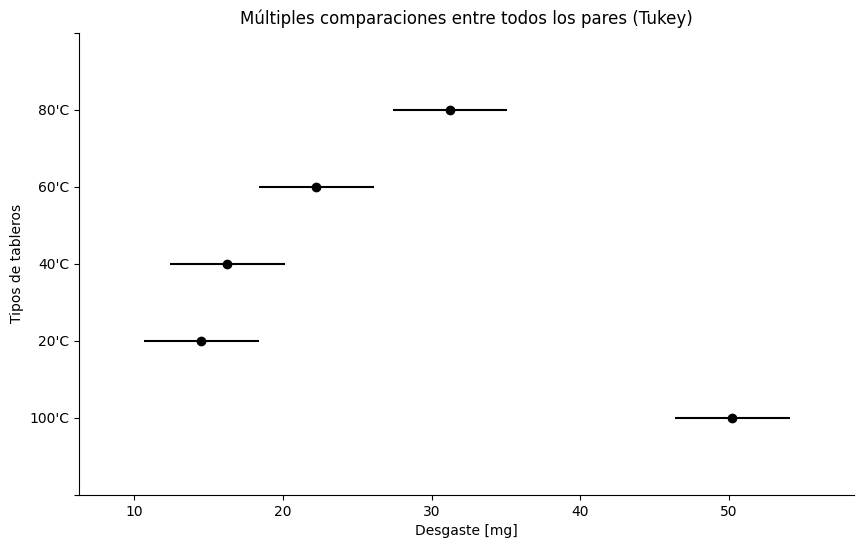

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['temperatura'], # Variable de respuesta
    groups=df['tableros'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tipos de tableros", xlabel="Desgaste [mg]")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["tableros"]).mean()["temperatura"]

,temperatura
tableros,
100'C,50.25
20'C,14.50
40'C,16.25
60'C,22.25
80'C,31.25


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(tableros)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.948


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["tableros"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9478
f de Cohen = 4.2600
Potencia de la prueba = 1.0000


**CONCLUSION**

Analizando la base de datos los tableros electrónicos de los carros nos sometemos a un envejecimiento durante 100 horas a un acierta temperatura y la variable se mide la intensidad de la corriente que circulaba por 2 puntos.

Se probaron 20 modelos a 5 diferentes temperaturas. Para ver cual temperatura conviene más tenemos que hacer diferentes test de los cuales el shapiro nos dio un resultado de $.7785$ lo que indica que si hay normalidad, del test de levene nos dio un resultado de $.6160$ lo que significa que si hay homocedasticidad.

Una vez que vemos que los test si cumplen con su objetivo hacemos el test de tukey y vemos que las temperaturas que son mejores son de 20 y 40 grados centígrados pero como recomendación no tener el tablero a una temperatura de 100 grados ya que puede ser muy peligroso.

5. En una empresa de manufactura se propone un tratamiento para reducir el porcentaje de productos defectuosos. Para validar esta propuesta se diseñó un experimento en el que se producía con o sin la propuesta de mejora. Cada corrida experimental consistió en producir un lote y la variable de respuesta es el porcentaje de producto defectuoso. Se hicieron 25 réplicas para cada tratamiento. Los datos obtenidos se muestran a continuación:

| Tratamiento     | Porcentaje de producto defectuoso                                     |
|-----------------|----------------------------------------------------------------------|
| Con tratam.     | 5.3, 4.0, 4.0, 4.0, 2.6, 2.1, 5.1, 4.1, 4.1, 3.2, 5.1, 2.2, 4.1     |
| Sin tratam.     | 8.0, 13.2, 7.2, 8.2, 9.1, 6.7, 12.6, 16.3, 9.2, 6.4, 7.2, 17.2, 12.3 |


In [ ]:
# Oscar Said Valenciano Gallegos
import pandas as pd
from io import StringIO

datos='''
tratamiento,productos
C/T,5.3
S/T,8.0
C/T,4.0
S/T,13.2
C/T,4.0
S/T,7.2
C/T,4.0
S/T,8.2
C/T,2.6
S/T,9.1
C/T,2.1
S/T,6.7
C/T,5.1
S/T,12.6
C/T,4.1
S/T,16.3
C/T,4.1
S/T,9.2
C/T,3.2
S/T,6.4
C/T,5.1
S/T,7.2
C/T,2.2
S/T,17.2
C/T,4.1
S/T,12.3
'''

df=pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)
df

,tratamiento,productos
0,C/T,5.3
1,S/T,8.0
2,C/T,4.0
3,S/T,13.2
4,C/T,4.0
5,S/T,7.2
6,C/T,4.0
7,S/T,8.2
8,C/T,2.6
9,S/T,9.1


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Hipotesis
#H0: mu_1 = mu_2 = mu_3
#H1: al menos una media es diferente

modelo = ols('productos~ C(tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) #round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tratamiento),269.4496,1.0,37.1028,0.0
Residual,174.2938,24.0,NaN,NaN


Aqui tuvimos que usar el codigo de anova para comparar las medias, de parte de la variabilidad explicada por el tipo de cuero nos dio 269.4496

In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.08240142335255941


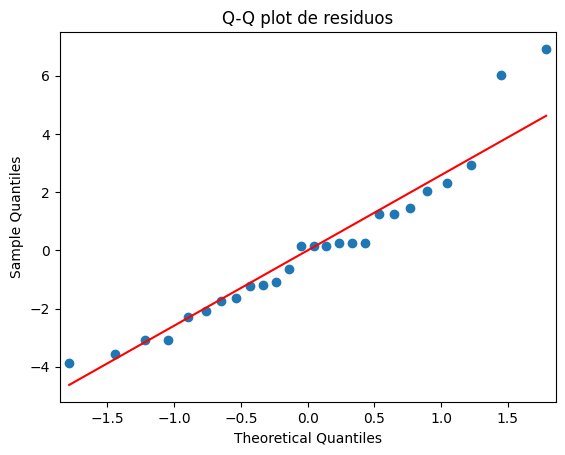

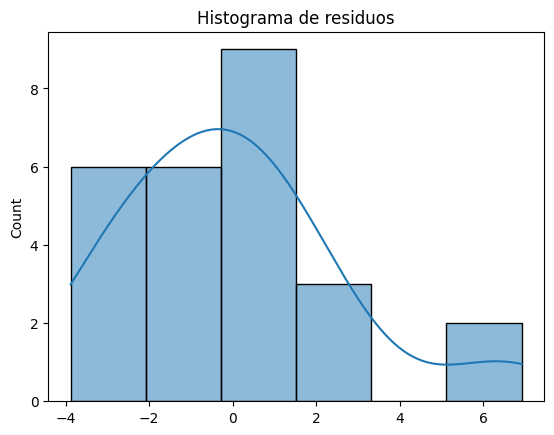

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals from the fitted model
residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

Haciendo el test de de shapiro wilk, lo que nos dio un resultado de $.0824$, lo que nos indica que **hay normalidad**

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['tratamiento'] == 'C/T']['productos']
grupo_B = df[df['tratamiento'] == 'S/T']['productos']


stat, p = levene(grupo_A, grupo_B)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 8.7144
p-valor: 0.0070


De parte del test de levene, nos dio un resultado de $.0070$ lo que signifa que es muy fuerte y significa que **no hay homocedasticidad**

Como el test de levene nos cumplio su objetivo tenemos que hacer el metodo de boxcox para que los 2 test cumplan sus objetivos

Lambda óptimo: -0.05387225396368365


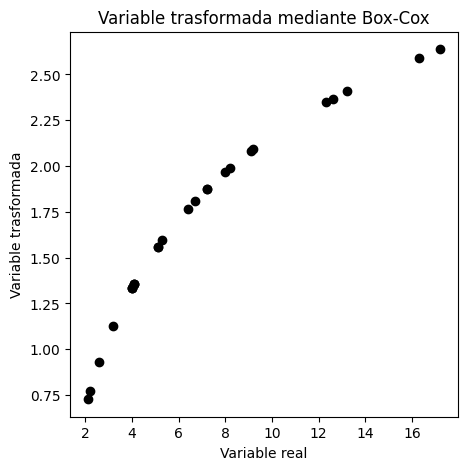

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["productos_boxcox"], lambda_opt = boxcox(df["productos"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["productos"], df["productos_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('productos_boxcox ~ C(tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(tratamiento),5.0403,1.0,58.8438,0.0
Residual,2.0557,24.0,NaN,NaN


Con el metodo tenemos otro resultado del anova lo que nos dio un resultado de 5.0403

In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.5855089577225056


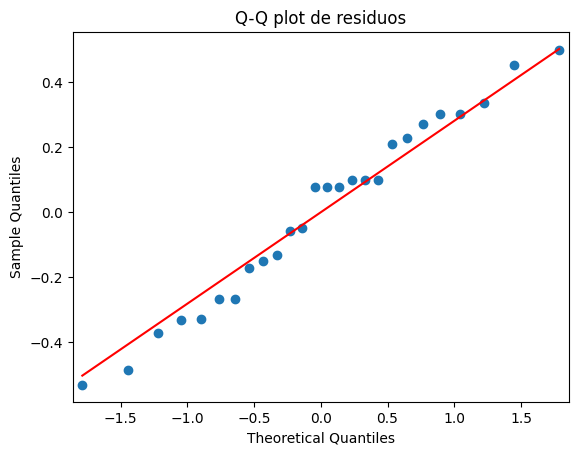

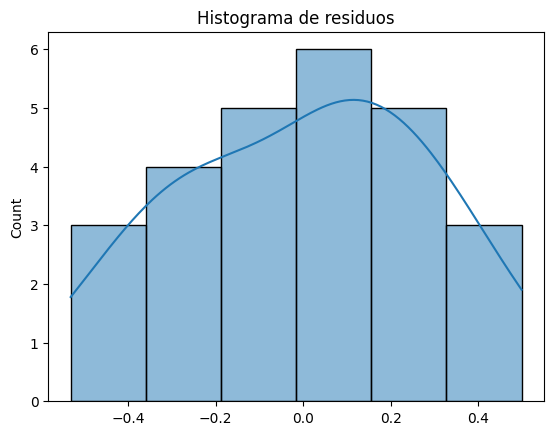

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Haciendo otra vez el test de de shapiro wilk, lo que nos dio un resultado de $.5855$, lo que nos indica que **hay normalidad**

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['tratamiento'] == 'C/T']['productos_boxcox']
grupo_B = df[df['tratamiento'] == 'S/T']['productos_boxcox']

stat, p = levene(grupo_A, grupo_B)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.3797
p-valor: 0.5436


Como hicimos el metodod de boxcox de parte del test de levene, nos dio un resultado de $.5436$ lo que signifa que es muy fuerte y significa que **hay homocedasticidad**

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
   C/T    S/T   0.8806   0.0 0.6437 1.1175   True
-------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

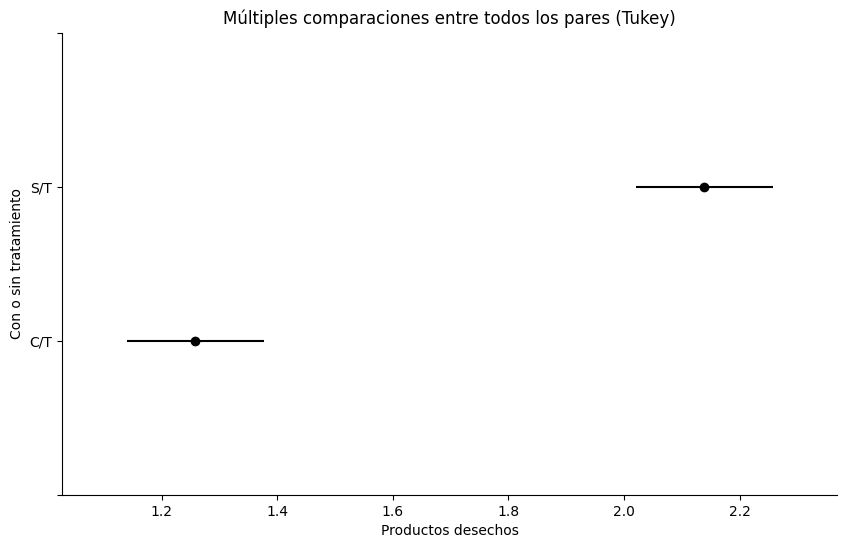

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['productos_boxcox'], # Variable de respuesta
    groups=df['tratamiento'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Con o sin tratamiento", xlabel="Productos desechos")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["tratamiento"]).mean()["productos"]

,productos
tratamiento,
C/T,3.838462
S/T,10.276923


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(tratamiento)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.710


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["tratamiento"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.7103
f de Cohen = 1.5658
Potencia de la prueba = 1.0000


**CONCLUISION**

Probamos los metodos de anova, despues nos fuimos con el testvde shapiro y nos dio un valor de $0.0824$ que indica que si hubo normalidad. Ahora nos pasamos al test de levene el cual nos dio un resultado de $0.007$ lo cual nos inidca que no hubo homocedasticidad.
Por lo que tenemos que uar el metodo de boxcox lo que nos indica que tenemos que hacer los test de nuevo, de lo cual de shapiro nos dio un resultado de $0.5855$ lo cual indica que hay normalidad y de parte del test de levene tuvimos un total de 0.543 lo cual nos indica que si hubo homocedasticidad.
Analizando el test de tukey nos dice que con tratamiento hay 1% producto desecho pero si no hacemos tratamiento nos da 2% productos desechos y lo que queremos es minimizar los productos. Ademas que en promedio nos da $3.83%$ de productos desechos con tratamiento y sin tratamiento nos da 10.27% asi que lo recomendable es hacer el tratamiento para minimizar los productos desechos

6. Una compañía farmacéutica desea evaluar el efecto que tiene la cantidad de almidón en la dureza de las tabletas. Se decidió producir lotes con una cantidad determinada de almidón, y que las cantidades de almidón a aprobar fueran 2%, 5% y 10%. La variable de respuesta sería el promedio de la dureza de 20 tabletas de cada lote. Se hicieron 4 réplicas por tratamiento y se obtuvieron los siguientes resultados:

| % de almidón | Dureza               |
|--------------|----------------------|
| 2            | 4.3, 5.2, 4.8, 4.5  |
| 5            | 6.5, 7.3, 6.9, 6.1  |
| 10           | 9.0, 7.8, 8.5, 8.1  |


In [ ]:
# Oscar Said Valenciano Gallegos
import pandas as pd
from io import StringIO

datos='''
almidon,dureza
2,4.3
5,6.5
10,9.0
2,5.2
5,7.3
10,7.8
2,4.8
5,6.9
10,8.5
2,4.5
5,6.1
10,8.1

'''

df=pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)
df

,almidon,dureza
0,2,4.3
1,5,6.5
2,10,9.0
3,2,5.2
4,5,7.3
5,10,7.8
6,2,4.8
7,5,6.9
8,10,8.5
9,2,4.5


In [ ]:
df. columns

Index(['almidon', 'dureza'], dtype='object')

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Hipotesis
#H0: mu_2 = mu_5 = mu_10
#H1: al menos una media es diferente

modelo = ols('dureza~ C(almidon)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) #round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(almidon),26.7267,2.0,58.1014,0.0
Residual,2.0700,9.0,NaN,NaN


Aqui tuvimos que usar el codigo de anova para comparar las medias, de parte de la variabilidad explicada por el tipo de cuero nos dio 26.7226

In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.42952068080371164


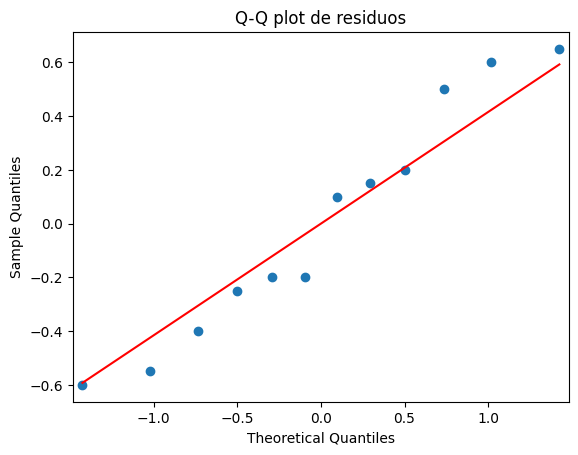

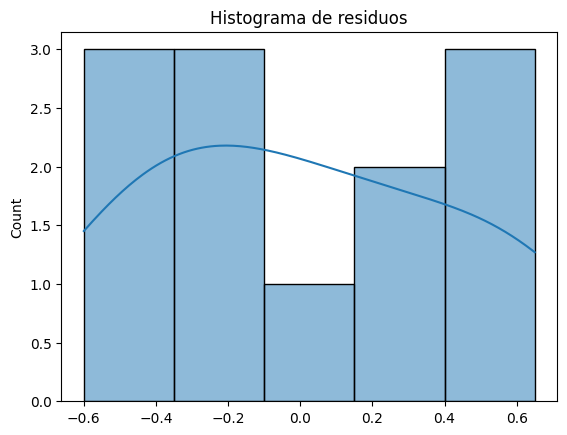

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals from the fitted model
residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

Haciendo el test de de shapiro wilk, lo que nos dio un resultado de $.4295$, lo que nos indica que **hay normalidad**

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['almidon'] == 2]['dureza']
grupo_B = df[df['almidon'] == 5]['dureza']
grupo_C = df[df['almidon'] == 10]['dureza']


stat, p = levene(grupo_A, grupo_B, grupo_C)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.2667
p-valor: 0.7718


De parte del test de levene, nos dio un resultado de $.7718$ lo que signifa que es muy fuerte y significa que **hay homocedasticidad**

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
     2      5      2.0 0.0006 1.0532 2.9468   True
     2     10     3.65    0.0 2.7032 4.5968   True
     5     10     1.65 0.0023 0.7032 2.5968   True
--------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

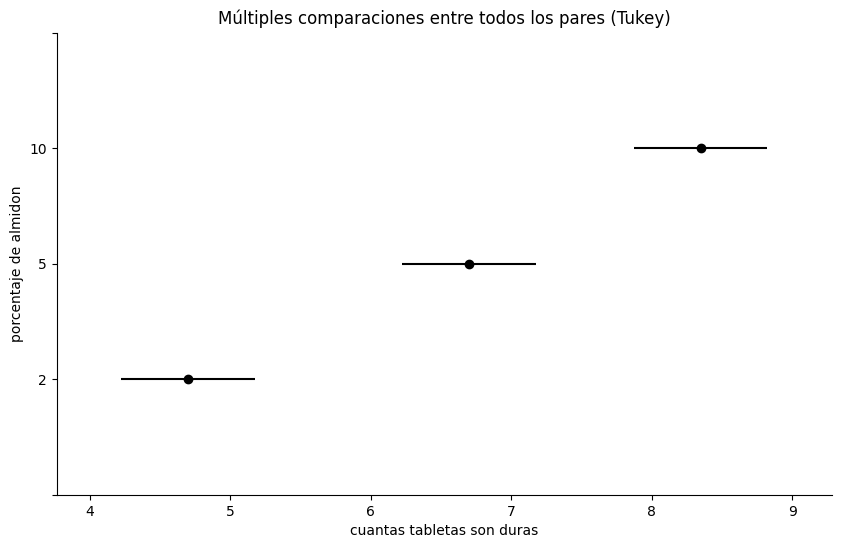

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['dureza'], # Variable de respuesta
    groups=df['almidon'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="porcentaje de almidon", xlabel="cuantas tabletas son duras")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["almidon"]).mean()["dureza"]

,dureza
almidon,
2,4.70
5,6.70
10,8.35


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(almidon)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.928


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["almidon"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9281
f de Cohen = 3.5932
Potencia de la prueba = 1.0000


**CONCLUSION**

Analizando la base de datos de una compañía farmacéutica este desea evaluar el efecto de la cantidad de almidón en la dureza de las tabletas y tienen 3 opciones para ponerle cierta cantidad de almidón a las tabletas será la correcta. Tenemos la opción de 2%, 5% y 10%.

 Para saber cual es la cantidad correcta de almidon, tenemos que usar los siguientes métodos, del test de shapiro nos dio un resultado de $.4295$ lo que significa que hay normalidad, de parte del test de levene nos dio un resultado de $.7718$ lo que significa que hay homocedasticidad. Ya que los 2 test cumplen con su objetivo hacemos el test de tukey que nos dice que con 10% de almidon alcanza a que 10 tabletas sean duras pero es mejor que sea 2% de almidon ya que alcanza 5 tabletas.

 Como recomendación es mejor usar 2% de almidón aunque sean menos duras las tabletas ya que ayuda para que sea más fácil de pasar  

7. Los datos que se presentan enseguida son rendimientos en toneladas por hectárea de un pasto con tres niveles de fertilización nitrogenada. El diseño fue completamente aleatorizado, con cinco repeticiones por tratamiento.

| Niveles de nitrógeno | Rendimientos (ton/ha)       |
|-----------------------|----------------------------|
| 1                     | 14.823, 14.676, 14.720, 14.5141, 15.065 |
| 2                     | 25.151, 25.401, 25.131, 25.031, 25.267 |
| 3                     | 32.605, 32.460, 32.256, 32.669, 32.111 |


In [ ]:
# Oscar Said Valenciano Gallegos
import pandas as pd
from io import StringIO

datos ='''
nitrogeno,rendimiento
1, 14.823
2, 25.151
3, 32.605
1, 14.676
2, 25.401
3, 32.460
1, 14.720
2, 25.131
3, 32.256
1, 14.5141
2, 25.031
3, 32.669
1, 15.065
2, 25.267
3, 32.111
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,nitrogeno,rendimiento
0,1,14.8230
1,2,25.1510
2,3,32.6050
3,1,14.6760
4,2,25.4010
5,3,32.4600
6,1,14.7200
7,2,25.1310
8,3,32.2560
9,1,14.5141


In [ ]:
df. columns

Index(['nitrogeno', 'rendimiento'], dtype='object')

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# Use the renamed columns in the ols formula
modelo = ols('rendimiento ~ C(nitrogeno)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales

,sum_sq,df,F,PR(>F)
C(nitrogeno),788.3408,2.0,10131.6193,0.0
Residual,0.4669,12.0,NaN,NaN


Aqui tuvimos que usar el codigo de anova para comparar las medias, de parte de la variabilidad explicada por el tipo de cuero nos dio 788.3408

In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.8890610190283594


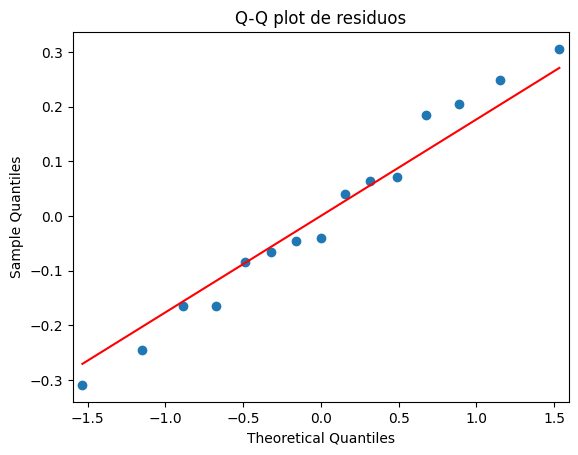

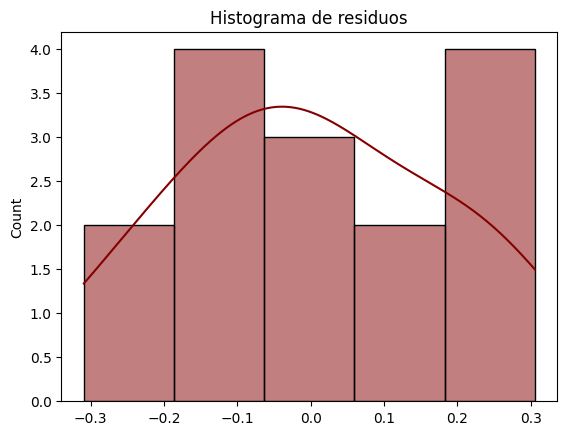

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True, color="#850000")
plt.title("Histograma de residuos")
plt.show()

Haciendo el test de de shapiro wilk, lo que nos dio un resultado de $.5978$, lo que nos indica que **hay normalidad**

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_1 = df[df['nitrogeno'] == 1]['rendimiento']
grupo_2 = df[df['nitrogeno'] == 2]['rendimiento']
grupo_3 = df[df['nitrogeno'] == 3]['rendimiento']


stat, p = levene(grupo_1, grupo_2, grupo_3)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.5372
p-valor: 0.5978


De parte del test de levene, nos dio un resultado de $.5978$ lo que signifa que es muy fuerte y significa que **hay homocedasticidad**

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
     1      2  10.4366   0.0 10.1038 10.7694   True
     1      3  17.6606   0.0 17.3278 17.9934   True
     2      3    7.224   0.0  6.8912  7.5568   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

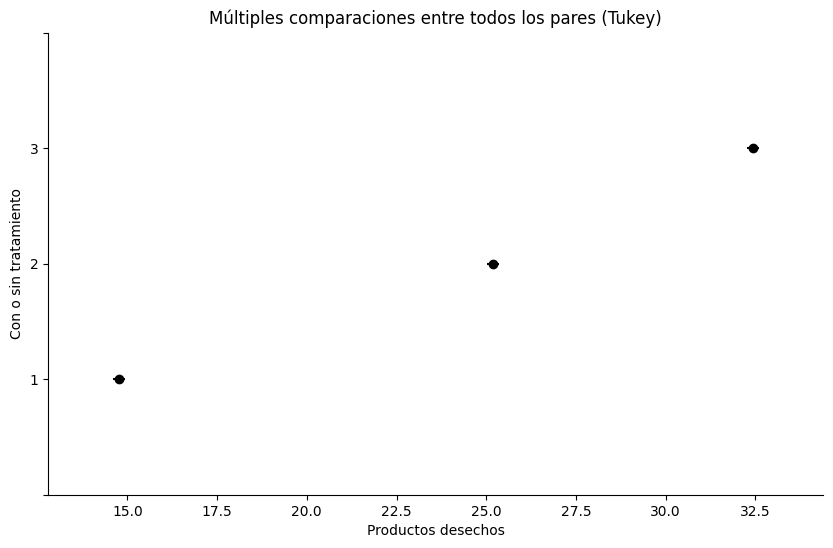

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['rendimiento'], # Variable de respuesta
    groups=df['nitrogeno'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Con o sin tratamiento", xlabel="Productos desechos")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["nitrogeno"]).mean()["rendimiento"]

,rendimiento
nitrogeno,
1,14.75962
2,25.19620
3,32.42020


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(nitrogeno)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.999


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["nitrogeno"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9994
f de Cohen = 41.0926
Potencia de la prueba = 1.0000


**CONCLUSION**

Analizando la base de datos queremos tener los rendimientos en toneladas que están por hectárea de un pasto de 3 niveles de fertilización. Para eso tenemos los 3 niveles de nitrógeno y lo pondremos a prueba con los rendimientos de toneladas por hectáreas.

Para saber cuál es la cantidad correcta de almidon, tenemos que usar los siguientes métodos, del test de shapiro nos dio un resultado de $.8890$ lo que significa que hay normalidad, de parte del test de levene nos dio un resultado de $.5978$ lo que significa que hay homocedasticidad. Ya que los 2 test cumplen con su objetivo hacemos el test de tukey que el primer nivel nitrógeno nos da 15 hectáreas pero como recomendación será el nivel 3 ya que dan hasta 32.5 hectáreas.  

8. Un químico del departamento de desarrollo de un laboratorio farmacéutico desea conocer cómo influye el tipo de aglutinante utilizado en tabletas de ampicilina de 500 mg en el porcentaje de friabilidad; para ello, se eligen los siguientes aglutinantes: polivinilpirrolidona (PVP), carboximetilcelulosa sódica (CMC) y grenetina (Gre). Los resultados del diseño experimental son los siguientes:

| Aglutinante | % de friabilidad          |
|-------------|---------------------------|
| PVP         | 0.485, 0.250, 0.073, 0.205, 0.161 |
| CMC         | 9.64, 9.37, 9.53, 9.86, 9.79       |
| Gre         | 0.289, 0.275, 0.612, 0.152, 0.137  |


In [ ]:
# Oscar Said Valenciano Gallegos
import pandas as pd
from io import StringIO

datos = """
Aglutinate,Friabilidad
PVP,0.485
CMC,9.64
GRE,0.289
PVP,0.250
CMC,9.37
GRE,0.275
PVP,0.073
CMC,9.53
GRE,0.612
PVP,0.205
CMC,9.86
GRE,0.152
PVP,0.161
CMC,9.79
GRE,0.137
"""

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,Aglutinate,Friabilidad
0,PVP,0.485
1,CMC,9.640
2,GRE,0.289
3,PVP,0.250
4,CMC,9.370
5,GRE,0.275
6,PVP,0.073
7,CMC,9.530
8,GRE,0.612
9,PVP,0.205


In [ ]:
df. columns

Index(['Aglutinate', 'Friabilidad'], dtype='object')

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Hipotesis
#H0: mu_PVP = mu_CMC = mu_GRE
#H1: al menos una media es diferente

modelo = ols('Friabilidad~ C(Aglutinate)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) #round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(Aglutinate),292.9210,2.0,4420.9726,0.0
Residual,0.3975,12.0,NaN,NaN


Aqui tuvimos que usar el codigo de anova para comparar las medias, de parte de la variabilidad explicada por el tipo de cuero nos dio 292.9210

In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.421434541938734


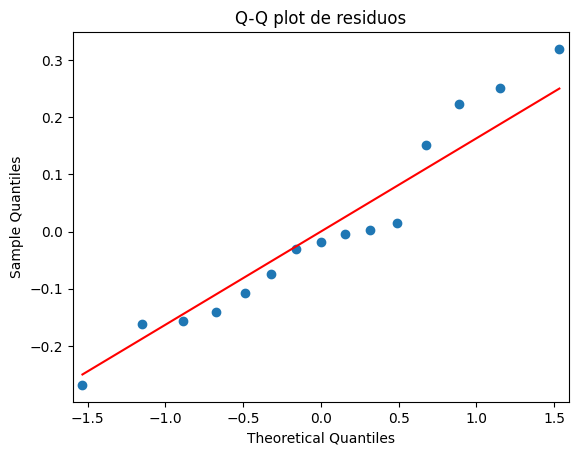

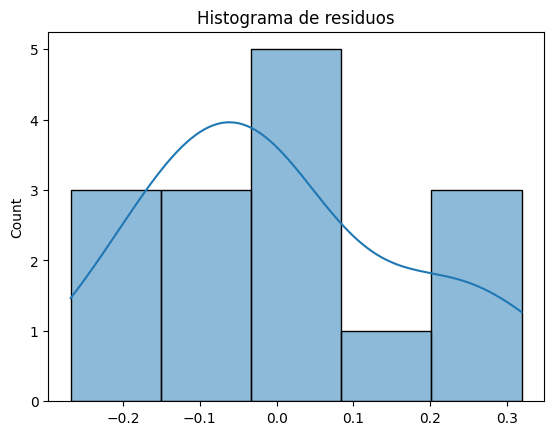

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals from the fitted model
residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

Haciendo el test de de shapiro wilk, lo que nos dio un resultado de $.4214$, lo que nos indica que **hay normalidad**

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_A = df[df['Aglutinate'] =='PVP']['Friabilidad']
grupo_B = df[df['Aglutinate'] =='CMC']['Friabilidad']
grupo_C = df[df['Aglutinate'] == 'GRE']['Friabilidad']


stat, p = levene(grupo_A, grupo_B, grupo_C)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.2250
p-valor: 0.8018


De parte del test de levene, nos dio un resultado de $.8018$ lo que signifa que es muy fuerte y significa que **hay homocedasticidad**

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
   CMC    GRE   -9.345   0.0 -9.6521 -9.0379   True
   CMC    PVP  -9.4032   0.0 -9.7103 -9.0961   True
   GRE    PVP  -0.0582  0.87 -0.3653  0.2489  False
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

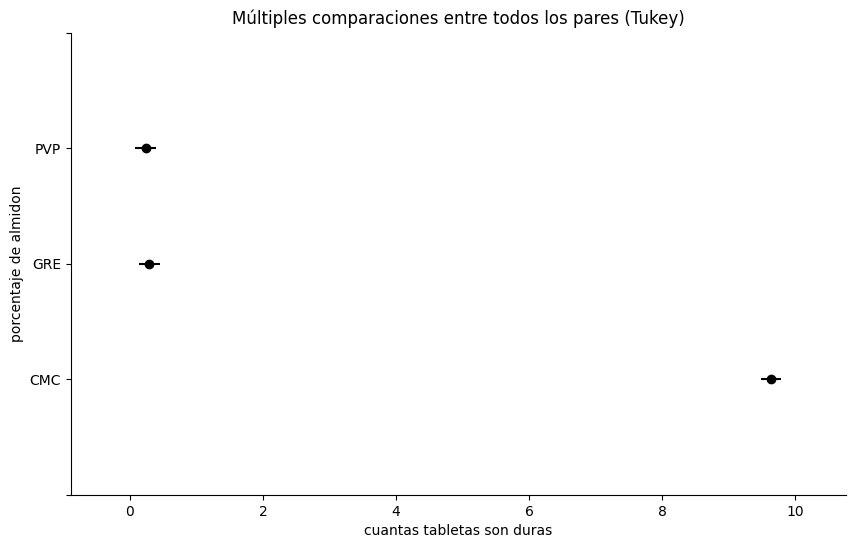

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Friabilidad'], # Variable de respuesta
    groups=df['Aglutinate'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="porcentaje de almidon", xlabel="cuantas tabletas son duras")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["Aglutinate"]).mean()["Friabilidad"]

,Friabilidad
Aglutinate,
CMC,9.6380
GRE,0.2930
PVP,0.2348


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(Aglutinate)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.999


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["Aglutinate"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.9986
f de Cohen = 27.1446
Potencia de la prueba = 1.0000


**CONCLUSION**

Analizando la base de datos de un laboratorio por parte de un laboratorio el cual quiere conocer el tipo de aglutínate para las tabletas de 500 mg y para ello se eligen 3 aglutinantes los cuales son (PVP), (CMC), (Gre) y para saber cuál aglutínate es mejor, tenemos que usar los siguientes métodos, del test de shapiro nos dio un resultado de $.4214$ lo que significa que hay normalidad, de parte del test de levene nos dio un resultado de $.8018$ lo que significa que hay homocedasticidad.

 Ya que los 2 test cumplen con su objetivo hacemos el test de tukey lo que nos dice que el mejor aglutínate es (CMC) lo cual nos da un total de 10 tabletas duras  

9. Se cultivaron cuatro diferentes clonas de *agave tequilana* bajo un mismo esquema de manejo. Se quiere saber qué clona es la que responde mejor a dicho manejo, evaluando el nivel de respuesta con el porcentaje de azúcares reductores totales en base húmeda. Los datos se muestran a continuación:

| Clona | Porcentaje de azúcares reductores totales |
|-------|------------------------------------------|
| 1     | 8.69, 6.68, 6.83, 6.43, 10.30            |
| 2     | 8.00, 16.41, 12.43, 10.99, 15.53         |
| 3     | 17.39, 13.73, 15.62, 17.05, 15.42        |
| 4     | 10.37, 9.16, 8.83, 4.40, 10.38           |


In [ ]:
# Oscar Said Valenciano Gallegos
import pandas as pd
from io import StringIO

datos='''
clona,azucar
1,8.69
2,8.00
3,17.39
4,10.37
1,6.68
2,16.41
3,13.73
4,9.16
1,6.83
2,12.43
3,15.62
4,8.83
1,6.43
2,10.99
3,17.05
4,4.40
1,10.30
2,15.53
3,15.42
4,10.38

'''

df=pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)
df

,clona,azucar
0,1,8.69
1,2,8.00
2,3,17.39
3,4,10.37
4,1,6.68
5,2,16.41
6,3,13.73
7,4,9.16
8,1,6.83
9,2,12.43


In [ ]:
df. columns

Index(['clona', 'azucar'], dtype='object')

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Hipotesis
#H0: mu_1 = mu_2 = mu_3 = mu_4
#H1: al menos una media es diferente

modelo = ols('azucar~ C(clona)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) #round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(clona),209.9072,3.0,12.3271,0.0002
Residual,90.8168,16.0,NaN,NaN


Aqui tuvimos que usar el codigo de anova para comparar las medias, de parte de la variabilidad explicada por el tipo de cuero nos dio 209.9072

In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.7677173153296002


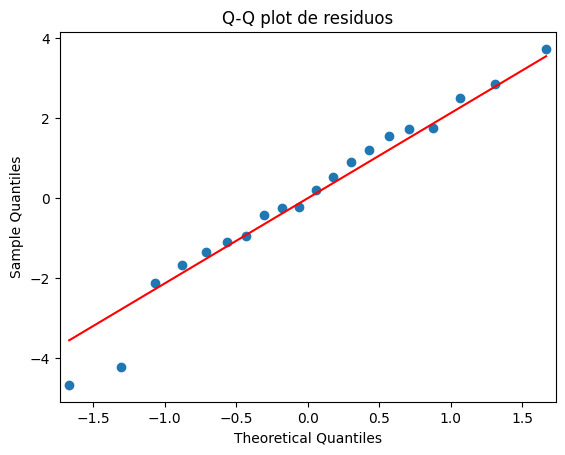

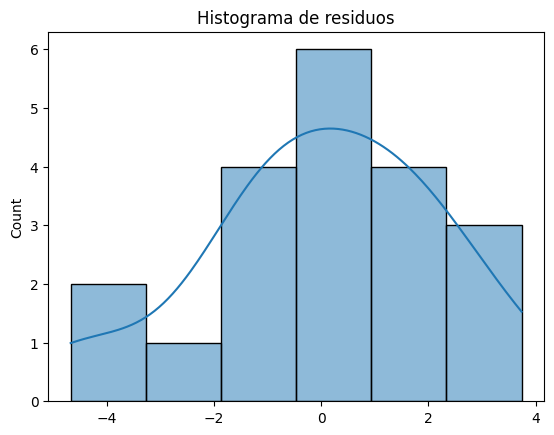

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals from the fitted model
residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

Haciendo el test de de shapiro wilk, lo que nos dio un resultado de $.7677$, lo que nos indica que **hay normalidad**

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_1 = df[df['clona'] == 1]['azucar']
grupo_2 = df[df['clona'] == 2]['azucar']
grupo_3 = df[df['clona'] == 3]['azucar']
grupo_4 = df[df['clona'] == 4]['azucar']


stat, p = levene(grupo_1, grupo_2, grupo_3, grupo_4)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.9749
p-valor: 0.4290


De parte del test de levene, nos dio un resultado de $.4290$ lo que signifa que es muy fuerte y significa que **hay homocedasticidad**

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2    4.886 0.0237   0.575  9.197   True
     1      3    8.056 0.0003   3.745 12.367   True
     1      4    0.842 0.9428  -3.469  5.153  False
     2      3     3.17 0.1939  -1.141  7.481  False
     2      4   -4.044 0.0699  -8.355  0.267  False
     3      4   -7.214  0.001 -11.525 -2.903   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

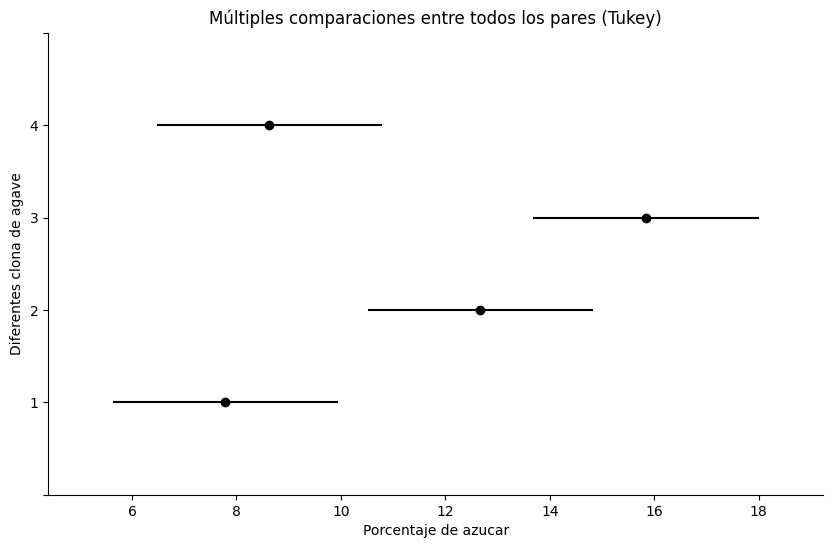

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['azucar'], # Variable de respuesta
    groups=df['clona'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Diferentes clona de agave", xlabel="Porcentaje de azucar")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["clona"]).mean()["azucar"]

,azucar
clona,
1,7.786
2,12.672
3,15.842
4,8.628


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(clona)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.698


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["clona"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.6980
f de Cohen = 1.5203
Potencia de la prueba = 0.9997


**CONCLUSION**

Analizando la base de datos vemos que 4 diferentes clonas de agave, se necesita ver cual clona es mejor para el manejo de agave tenemos que usar los siguientes métodos, del test de shapiro nos dio un resultado de $.7677$ lo que significa que hay normalidad, de parte del test de levene nos dio un resultado de $.4290$ lo que significa que hay homocedasticidad.

 Ya que los 2 test cumplen con su objetivo hacemos el test de tukey lo que nos dice que es mejor la clona 1 ya que nos da menor porcentaje de azugar en el agave

10. Uno de los defectos que causan mayor desperdicio en la manufactura de discos ópticos compactos son los llamados “cometas”. Típicamente, se trata de una partícula que opone resistencia al fluido en la etapa de entintado. Se quiere comprobar de manera experimental la efectividad de un tratamiento de limpieza de partículas que está basado en fuerza centrípeta y aire ionizado. A 12 lotes de 50 CD se les aplica el tratamiento y a otros 12 lotes no se les aplica; en cada caso se mide el porcentaje de discos que presentan cometas, los resultados son los siguientes:

| Con tratamiento      | Sin tratamiento      |
|----------------------|----------------------|
| 5.30   | 8.02  |
| 4.03   | 13.18 |
| 4.00   | 7.15  |
| 2.56   | 9.11  |
| 5.06   | 8.23  |
| 4.06   | 16.3  |
| 2.08   | 9.20  |
| 4.03   | 6.35  |
| 2.04   | 7.15  |
| 1.18   | 8.66  |


In [ ]:
# Oscar Said Valenciano Gallegos
import pandas as pd
from io import StringIO

datos='''
c/tratamiento,s/tratamiento
C/t,5.30
S/t,8.02
C/t,4.03
S/t,13.18
C/t,4.00
S/t,7.15
C/t,2.56
S/t,9.11
C/t,5.06
S/t,8.23
C/t,4.06
S/t,16.3
C/t,2.08
S/t,9.20
C/t,4.03
S/t,6.35
C/t,2.04
S/t,7.15
C/t,1.18
S/t,8.66
'''

df=pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)
df.columns = ['c_tratamiento', 's_tratamiento']
df

,c_tratamiento,s_tratamiento
0,C/t,5.30
1,S/t,8.02
2,C/t,4.03
3,S/t,13.18
4,C/t,4.00
5,S/t,7.15
6,C/t,2.56
7,S/t,9.11
8,C/t,5.06
9,S/t,8.23


In [ ]:
df. columns

Index(['c_tratamiento', 's_tratamiento'], dtype='object')

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

#Hipotesis
#H0: mu_C = mu_S
#H1: al menos una media es diferente

modelo = ols('s_tratamiento ~ C(c_tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) #round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(c_tratamiento),174.1090,1.0,30.6057,0.0
Residual,102.3981,18.0,NaN,NaN


Aqui tuvimos que usar el codigo de anova para comparar las medias, de parte de la variabilidad explicada por el tipo de cuero nos dio 174.1090

valor-p (Shapiro) = 0.013152795271816523


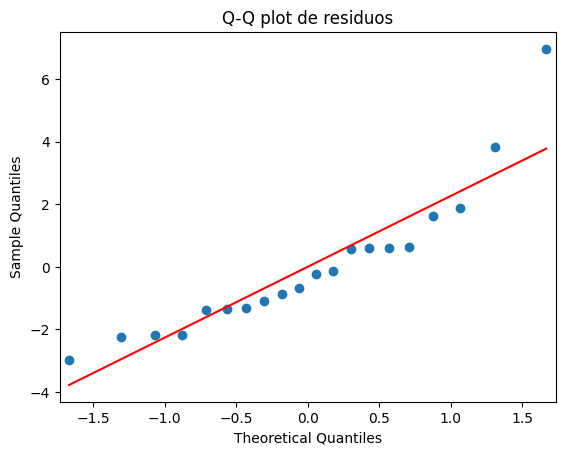

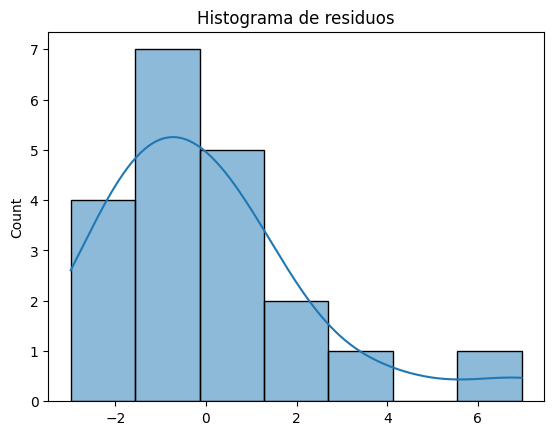

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Get residuals from the fitted model
residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

De parte del test de shapiro nos dio un resultado de $.0113$ lo que significa que no hay normalidad

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_C = df[df['c_tratamiento'] == 'C/t']['s_tratamiento']
grupo_S = df[df['c_tratamiento'] == 'S/t']['s_tratamiento']


stat, p = levene(grupo_C, grupo_S)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 1.1180
p-valor: 0.3043


De parte del test de levene, vemos que nos dio .3043 lo que significa que si hay homocedasticidad

Como vemos que de un metodo no cumple, entonces tenemos que usar el metodo de boxcox

Lambda óptimo: 0.3206116786631181


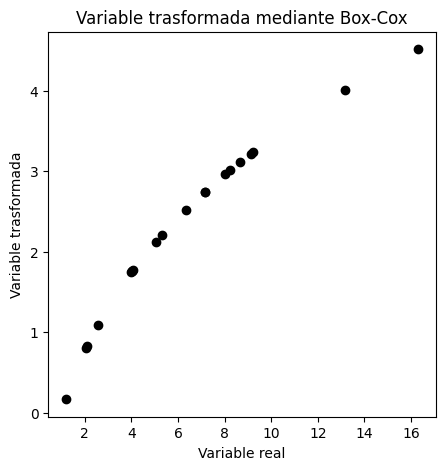

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["s_tratamiento_boxcox"], lambda_opt = boxcox(df["s_tratamiento"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["s_tratamiento"], df["s_tratamiento_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

In [ ]:
# ANOVA
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

# variable de respuesta ~ tratamiento
modelo = ols('s_tratamiento_boxcox ~ C(c_tratamiento)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(c_tratamiento),15.8598,1.0,38.9108,0.0
Residual,7.3367,18.0,NaN,NaN


In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.9455348292593064


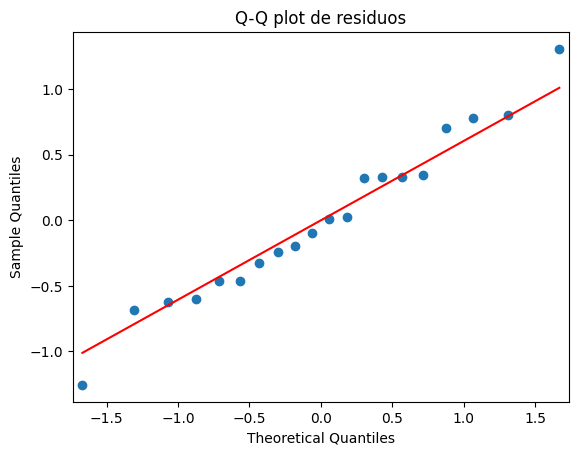

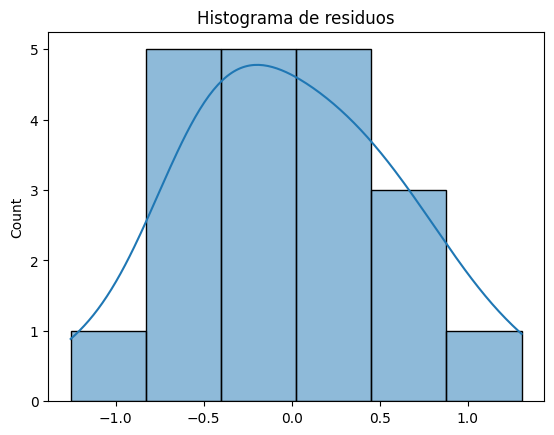

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Una vez hecho el metodo de boxcox tenemos un resultado de .9455 lo que significa que si hay normalidad

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_C = df[df['c_tratamiento'] == 'C/t']['s_tratamiento_boxcox']
grupo_S = df[df['c_tratamiento'] == 'S/t']['s_tratamiento_boxcox']


stat, p = levene(grupo_C, grupo_S)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.1523
p-valor: 0.7009


De parte del test de levene, despues del metodo de boxcox nos dio un resultado de .7009 lo que significa que hay homocedasticidad

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
   C/t    S/t    1.781   0.0 1.1812 2.3808   True
-------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

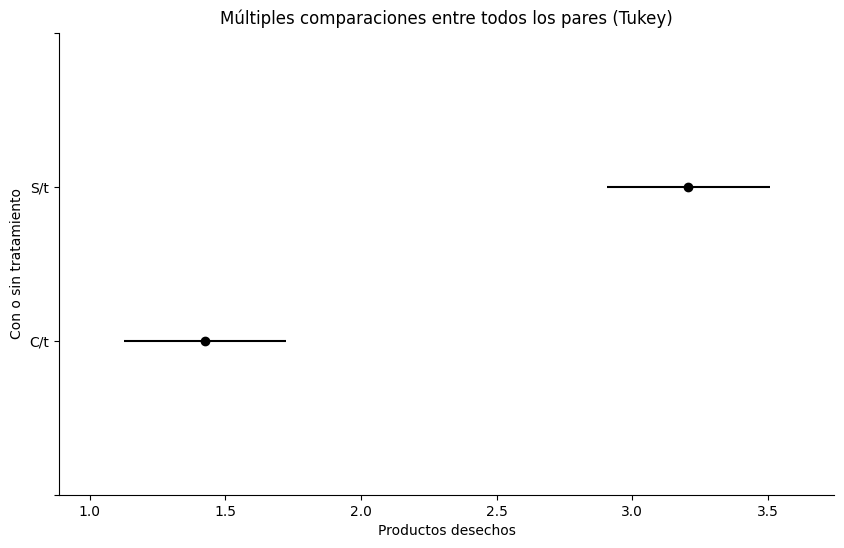

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['s_tratamiento_boxcox'], # Variable de respuesta
    groups=df['c_tratamiento'],  # Tratamiento
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Con o sin tratamiento", xlabel="Productos desechos")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
# Calcular promedios de cada método
df.groupby(["c_tratamiento"]).mean()["s_tratamiento"]

,s_tratamiento
c_tratamiento,
C/t,3.434
S/t,9.335


In [ ]:
# η² (eta cuadrado)	Tamaño del efecto
# ~0.01	              Pequeño
# ~0.06	              Mediano
# ~0.14 o más	        Grande

# Se interpreta como el coeficiente de determinación

# Estos valores pueden variar según la disciplina. En estudios de ciencias
# sociales, un η² de 0.06 puede ser muy significativo;
# en física o ingeniería, quizá se espera más.

from math import sqrt

eta_squared = tabla_anova['sum_sq']['C(c_tratamiento)'] / tabla_anova['sum_sq'].sum()
print(f"η² (tamaño de efecto): {eta_squared:.3f}")

η² (tamaño de efecto): 0.684


In [ ]:
from statsmodels.stats.power import FTestAnovaPower
import numpy as np

alpha = 0.05
k_grupos = df["c_tratamiento"].nunique()
n_total = len(df)

# Tamaño de efecto para ANOVA
f_cohen = np.sqrt(eta_squared / (1 - eta_squared))

# Potencia de la prueba ANOVA
analisis_potencia = FTestAnovaPower()

potencia = analisis_potencia.power(
    effect_size=f_cohen,
    nobs=n_total,
    alpha=alpha,
    k_groups=k_grupos
)

print(f"η² = {eta_squared:.4f}")
print(f"f de Cohen = {f_cohen:.4f}")
print(f"Potencia de la prueba = {potencia:.4f}")

η² = 0.6837
f de Cohen = 1.4703
Potencia de la prueba = 1.0000


**CONCLUSION**

Hemos hecho un análisis y seguido un procedimiento que les mostraremos a continuación, de parte del test de anova nos dio una variabilidad de 174.1090 que nos dio por el tipo de cuero, de parte de shapiro wilk nos dio .0113, lo que significa que no sigue normalidad, en cambio de parte del test de levene nos dio .3043 lo que significa que si hay homocedasticidad. Sin embargo, de parte del test de shapiro no cumple, entonces tenemos que usar el método de boxcox.

Una vez hecho el método de boxcox vemos que ya cumplen los dos test, de parte de shapiro nos dio .9455 lo que significa que si hay normalidad y de parte de levene nos dio .7009 lo que significa que si hay homocedasticidad.

Una vez que los dos test nos cumplan con su objetivo que es la normalidad y la homocedasticidad vemos que lo mejor es que lo hagan con tratamiento.
